In [1]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn import datasets
import matplotlib.pyplot as plt
sns.set()

In [2]:
df = pd.read_csv("../data/digits.csv")
df.head(15)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,number_label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
5,0.0,0.0,12.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,9.0,16.0,16.0,10.0,0.0,0.0,5
6,0.0,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,9.0,15.0,11.0,3.0,0.0,6
7,0.0,0.0,7.0,8.0,13.0,16.0,15.0,1.0,0.0,0.0,...,0.0,0.0,0.0,13.0,5.0,0.0,0.0,0.0,0.0,7
8,0.0,0.0,9.0,14.0,8.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,15.0,11.0,1.0,0.0,8
9,0.0,0.0,11.0,12.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,9.0,12.0,13.0,3.0,0.0,0.0,9


# EDAs

In [3]:
pixels = df.drop('number_label', axis=1)

In [4]:
single_img = pixels.iloc[0]
single_img.to_numpy().shape

(64,)

In [5]:
print(single_img.to_numpy().reshape(8,8))

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


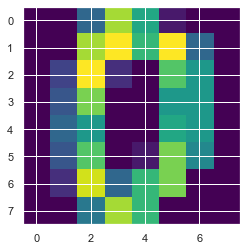

In [6]:
plt.imshow(single_img.to_numpy().reshape(8,8), cmap='viridis')

<AxesSubplot:>

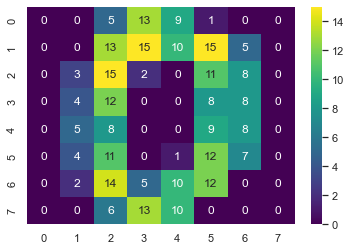

In [7]:
sns.heatmap(single_img.to_numpy().reshape(8,8), cmap='viridis', annot=True)

# Modelado base

In [8]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

def calc_predictions(X_train, X_test, y_train, y_test):

    df_results = pd.DataFrame(columns=['model_name', 'accuracy', 'precision', 'recall_sensitivity', 'f1'])

    models = [
        LogisticRegression(max_iter=10000),
        KNeighborsClassifier(n_neighbors=11),
        SVC(),
        DecisionTreeClassifier(),
        RandomForestClassifier(n_estimators=50),
        AdaBoostClassifier(n_estimators=100),
        GradientBoostingClassifier(n_estimators=100)
    ]

    for model in models:
        # entrenamiento y predicciones
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # classification metrics
        model_name = model.__class__.__name__
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='micro')
        recall_sensitivity = recall_score(y_test, y_pred, average='micro')
        f1 = f1_score(y_test, y_pred, average='micro')

        # guardar resultados
        row = [model_name, accuracy, precision, recall_sensitivity, f1]
        df_results.loc[len(df_results)] = row

    return df_results

In [9]:
X = df.drop('number_label', axis=1)
y = df['number_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
%%time
calc_predictions(X_train, X_test, y_train, y_test)

Wall time: 9.82 s


,model_name,accuracy,precision,recall_sensitivity,f1
0,LogisticRegression,0.973333,0.973333,0.973333,0.973333
1,KNeighborsClassifier,0.980000,0.980000,0.980000,0.980000
2,SVC,0.986667,0.986667,0.986667,0.986667
3,DecisionTreeClassifier,0.871111,0.871111,0.871111,0.871111
4,RandomForestClassifier,0.968889,0.968889,0.968889,0.968889
5,AdaBoostClassifier,0.335556,0.335556,0.335556,0.335556
6,GradientBoostingClassifier,0.971111,0.971111,0.971111,0.971111


# Escalado

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
%%time
calc_predictions(X_train_scaled, X_test_scaled, y_train, y_test)

Wall time: 8.97 s


,model_name,accuracy,precision,recall_sensitivity,f1
0,LogisticRegression,0.971111,0.971111,0.971111,0.971111
1,KNeighborsClassifier,0.980000,0.980000,0.980000,0.980000
2,SVC,0.988889,0.988889,0.988889,0.988889
3,DecisionTreeClassifier,0.873333,0.873333,0.873333,0.873333
4,RandomForestClassifier,0.975556,0.975556,0.975556,0.975556
5,AdaBoostClassifier,0.335556,0.335556,0.335556,0.335556
6,GradientBoostingClassifier,0.971111,0.971111,0.971111,0.971111


# PCA 2d

In [16]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
pca_2d.fit(X_train_scaled)

X_train_scaled_pca_2d = pca_2d.transform(X_train_scaled)
X_test_scaled_pca_2d = pca_2d.transform(X_test_scaled)

In [17]:
sum(pca_2d.explained_variance_ratio_)

0.281662355381086

In [18]:
%%time
calc_predictions(X_train_scaled_pca_2d, X_test_scaled_pca_2d, y_train, y_test)

Wall time: 2.89 s


,model_name,accuracy,precision,recall_sensitivity,f1
0,LogisticRegression,0.626667,0.626667,0.626667,0.626667
1,KNeighborsClassifier,0.655556,0.655556,0.655556,0.655556
2,SVC,0.655556,0.655556,0.655556,0.655556
3,DecisionTreeClassifier,0.553333,0.553333,0.553333,0.553333
4,RandomForestClassifier,0.622222,0.622222,0.622222,0.622222
5,AdaBoostClassifier,0.224444,0.224444,0.224444,0.224444
6,GradientBoostingClassifier,0.622222,0.622222,0.622222,0.622222


In [24]:
from sklearn.preprocessing import StandardScaler

# X_scaled = MinMaxScaler().fit_transform(X)
X_scaled = StandardScaler().fit_transform(X)
X_scaled_pca = PCA(n_components=2).fit_transform(X_scaled)
X_scaled_pca

array([[ 1.91421778, -0.95452821],
       [ 0.58898124,  0.92459082],
       [ 1.30202642, -0.3172542 ],
       ...,
       [ 1.02259934, -0.14790345],
       [ 1.07606124, -0.38096798],
       [-1.25769612, -2.22751467]])

<AxesSubplot:>

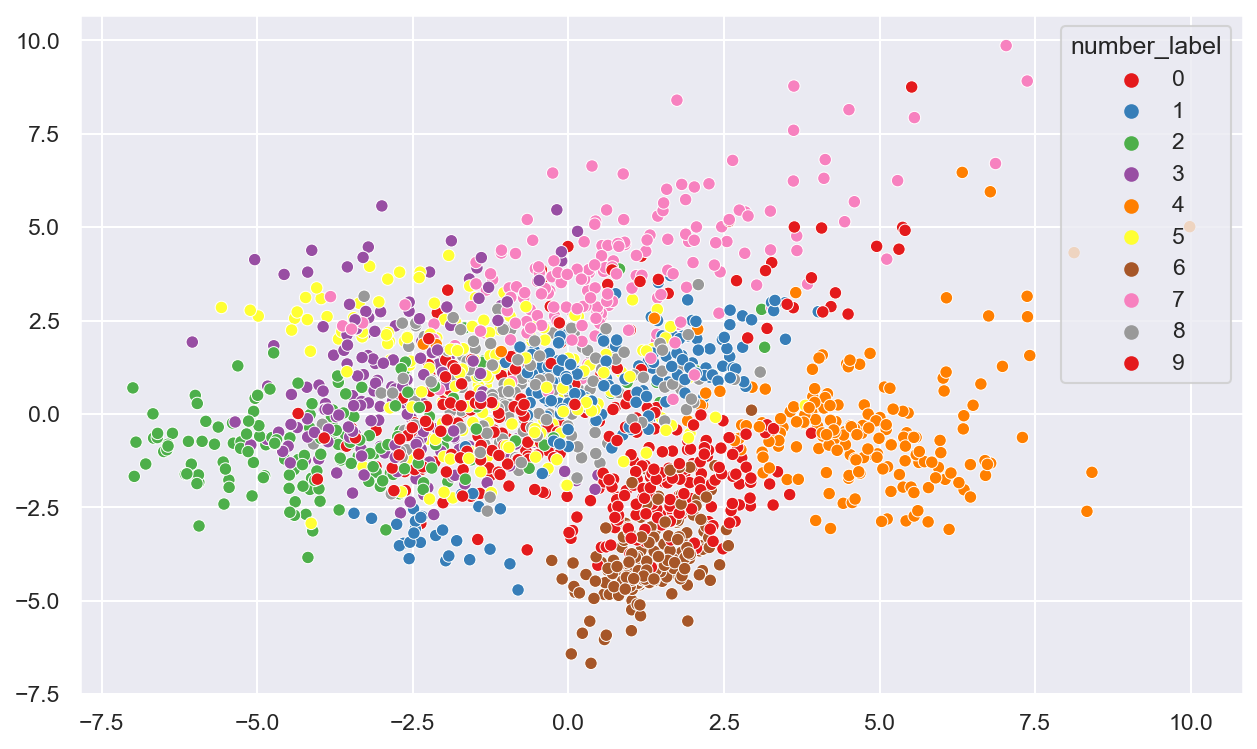

In [25]:
labels = df['number_label']
plt.figure(figsize=(10,6), dpi=150)
sns.scatterplot(data=X_scaled_pca, x=X_scaled_pca[:, 0], y=X_scaled_pca[:, 1], hue=labels, palette='Set1')

# PCA 3d

In [27]:
pca_3d = PCA(n_components=3)
pca_3d.fit(X_train_scaled)

X_train_scaled_pca_3d = pca_3d.transform(X_train_scaled)
X_test_scaled_pca_3d = pca_3d.transform(X_test_scaled)
sum(pca_3d.explained_variance_ratio_)

0.4019855527902585

In [28]:
%%time
calc_predictions(X_train_scaled_pca_3d, X_test_scaled_pca_3d, y_train, y_test)

Wall time: 4.44 s


,model_name,accuracy,precision,recall_sensitivity,f1
0,LogisticRegression,0.702222,0.702222,0.702222,0.702222
1,KNeighborsClassifier,0.791111,0.791111,0.791111,0.791111
2,SVC,0.766667,0.766667,0.766667,0.766667
3,DecisionTreeClassifier,0.693333,0.693333,0.693333,0.693333
4,RandomForestClassifier,0.760000,0.760000,0.760000,0.760000
5,AdaBoostClassifier,0.224444,0.224444,0.224444,0.224444
6,GradientBoostingClassifier,0.751111,0.751111,0.751111,0.751111


In [29]:
# X_scaled = MinMaxScaler().fit_transform(X)
X_scaled = StandardScaler().fit_transform(X)
X_scaled_pca = PCA(n_components=3).fit_transform(X_scaled)
X_scaled_pca

array([[ 1.91421325, -0.95448184, -3.94598911],
       [ 0.58897781,  0.92458955,  3.92476334],
       [ 1.30205457, -0.31724368,  3.02260492],
       ...,
       [ 1.02259568, -0.14787406,  2.47017196],
       [ 1.07605227, -0.38087266, -2.45519458],
       [-1.25770737, -2.22750028,  0.28406832]])

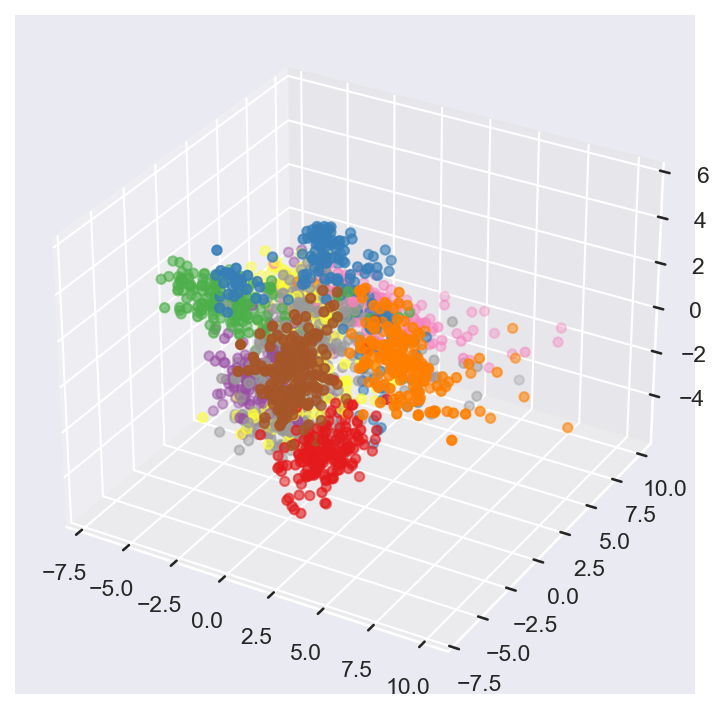

In [33]:
labels = df['number_label']
plt.figure(figsize=(10, 6), dpi=150)
ax = plt.axes(projection='3d')
ax.scatter3D(X_scaled_pca[:, 0], X_scaled_pca[:, 1], X_scaled_pca[:, 2], c=labels, cmap='Set1')

In [34]:
import plotly.express as px
df = pd.DataFrame(X_scaled_pca, columns=['PC1', 'PC2', 'PC3'])
df

,PC1,PC2,PC3
0,1.914213,-0.954482,-3.945989
1,0.588978,0.924590,3.924763
2,1.302055,-0.317244,3.022605
3,-3.020775,-0.868821,-0.801722
4,4.528951,-1.093425,0.973065
...,...,...,...
1792,0.104325,0.255015,-3.765578
1793,2.423239,-1.429690,-3.045471
1794,1.022596,-0.147874,2.470172
1795,1.076052,-0.380873,-2.455195


In [35]:
fig = px.scatter_3d(df, x='PC1', y='PC2', z='PC3', color=labels, )
fig.show()

# Dataset extendido

In [36]:
mnist = datasets.fetch_openml("mnist_784")

In [37]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [38]:
df = pd.DataFrame(mnist.data, columns=mnist.feature_names)
df['class'] = mnist.target
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [42]:
df.shape

(70000, 785)

In [39]:
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# %%time
# CUIDADO: puede tardar bastante tiempo
# calc_predictions(X_train, X_test, y_train, y_test)

In [46]:
# aplicando PCA:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=50)
pca.fit(X_train_scaled)

X_train_scaled_pca = pca.transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

print(X_train_scaled_pca.shape)
print(sum(pca.explained_variance_ratio_))

(52500, 50)
0.8255580575038269


In [ ]:
# %%time
# CUIDADO: puede tardar bastante tiempo
# Comprobar si tarda menos que el anterior
# calc_predictions(X_train_scaled_pca, X_test_scaled_pca, y_train, y_test)